# Tutorial 6.2: RC model identification and validation

This tutorial estimates a compact $1R1C$ controller model from noisy measurements generated by the independent reference plant. The model is evaluated on a later, untouched period.

## Learning outcomes

By the end of the tutorial, you should be able to:

1. align thermal inputs with the temperature transition they cause;
2. fit bounded coefficients using physical knowledge;
3. recover effective $R$, $C$ and $	au$ values; and
4. distinguish one-step validation from free rollout.

## Indicative schedule

- data inspection and alignment: 15 minutes;
- least-squares fitting: 25 minutes;
- parameter recovery: 15 minutes;
- validation and residuals: 30 minutes;
- discussion: 5 minutes.

The optional occupied-house extension adds approximately 30 minutes and can also be completed independently after class.

## 1. Set-up and data

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import lsq_linear

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    raise FileNotFoundError("Run this notebook from the repository root.")

plt.rcParams.update({"figure.figsize": (10, 4), "figure.dpi": 110})

Rows: 1,344
Period: 2025-01-06 00:00:00 to 2025-02-02 23:30:00
Duplicate timestamps: 0
Missing values: 0


,indoor_temperature_c,outdoor_temperature_c,heat_pump_modulation,heat_pump_electric_kw,delivered_heat_kw,cop,solar_irradiance_w_m2,internal_gains_kw,occupancy
timestamp,,,,,,,,,
2025-01-06 00:00:00,20.10870,6.12345,0.35,1.75,5.34830,3.05617,0.0,1.0,1.0
2025-01-06 00:30:00,20.28575,5.40370,0.35,1.75,5.28532,3.02018,0.0,1.0,1.0
2025-01-06 01:00:00,20.48672,6.02443,0.35,1.75,5.33964,3.05122,0.0,1.0,1.0
2025-01-06 01:30:00,20.54029,5.75881,0.35,1.75,5.31640,3.03794,0.0,1.0,1.0
2025-01-06 02:00:00,20.66100,5.06864,0.18,0.90,2.70309,3.00343,0.0,1.0,1.0


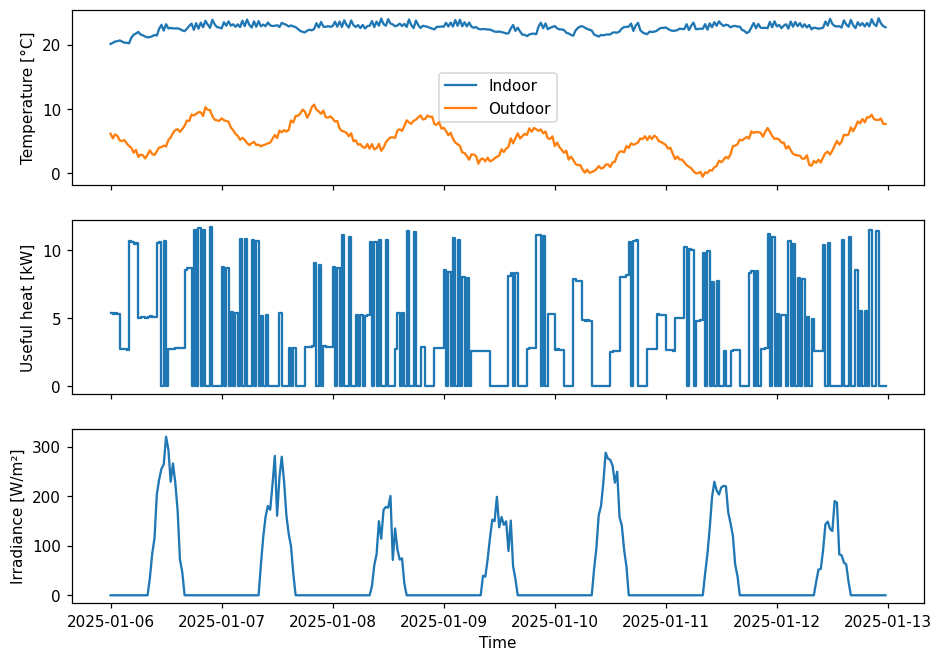

In [2]:
data = pd.read_csv(
    ROOT / "data" / "reference_building" / "identification_data.csv",
    index_col="timestamp",
    parse_dates=True,
).sort_index()

print(f"Rows: {len(data):,}")
print(f"Period: {data.index.min()} to {data.index.max()}")
print(f"Duplicate timestamps: {data.index.duplicated().sum()}")
print(f"Missing values: {int(data.isna().sum().sum())}")
display(data.head())

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 7))
window = data.iloc[: 7 * 48]
axes[0].plot(window["indoor_temperature_c"], label="Indoor")
axes[0].plot(window["outdoor_temperature_c"], label="Outdoor")
axes[0].set_ylabel("Temperature [°C]")
axes[0].legend()
axes[1].step(window.index, window["delivered_heat_kw"], where="post")
axes[1].set_ylabel("Useful heat [kW]")
axes[2].plot(window["solar_irradiance_w_m2"])
axes[2].set_ylabel("Irradiance [W/m²]")
axes[2].set_xlabel("Time")
plt.show()

## 2. Task 1 — aligned regression data

We fit the difference form

$$
T_{k+1}-T_k=b(T_{o,k}-T_k)+cq_{th,k}+\varepsilon_k
$$

where $b=\Delta t/(RC)$ and $c=\Delta t/C$. Inputs on row $k$ must be paired with the transition from $T_k$ to $T_{k+1}$.

In [3]:
def make_regression_table(data):
    table = data.copy()
    table["temperature_change_c"] = (
        table["indoor_temperature_c"].shift(-1) - table["indoor_temperature_c"]
    )
    table["temperature_difference_c"] = (
        table["outdoor_temperature_c"] - table["indoor_temperature_c"]
    )
    return table.iloc[:-1]

In [4]:
regression_table = make_regression_table(data)
split_time = data.index.min() + pd.Timedelta(days=21)
calibration = regression_table.loc[regression_table.index < split_time]
validation_data = data.loc[data.index >= split_time]

print(f"Calibration rows: {len(calibration):,}")
print(f"Validation rows: {len(validation_data):,}")

Calibration rows: 1,008
Validation rows: 336


## 3. Unconstrained worked example

In [5]:
design_calibration = calibration[["temperature_difference_c", "delivered_heat_kw"]].to_numpy()
target_calibration = calibration["temperature_change_c"].to_numpy()
unconstrained_coefficients, *_ = np.linalg.lstsq(
    design_calibration, target_calibration, rcond=None
)
print("Unconstrained coefficients:", unconstrained_coefficients)

Unconstrained coefficients: [0.0236022 0.1257613]


## 4. Task 2 — bounded estimation

Positive bounds encode the expected direction of outdoor heat exchange and heating. Bounds do not guarantee that the model is adequate; they prevent clearly impossible coefficient signs.

In [6]:
def fit_bounded_rc(regression_table):
    design = regression_table[["temperature_difference_c", "delivered_heat_kw"]].to_numpy()
    target = regression_table["temperature_change_c"].to_numpy()
    result = lsq_linear(design, target, bounds=([1e-5, 1e-5], [0.4, 0.5]))
    if not result.success:
        raise RuntimeError(result.message)
    return result.x

In [7]:
loss_coefficient, heat_coefficient = fit_bounded_rc(calibration)
print(f"Loss coefficient b: {loss_coefficient:.5f}")
print(f"Heating coefficient c: {heat_coefficient:.5f} °C/kW per step")

Loss coefficient b: 0.02360
Heating coefficient c: 0.12576 °C/kW per step


## 5. Task 3 — recover effective parameters

$$
C=\frac{\Delta t}{c},\qquad R=\frac{c}{b},\qquad \tau=RC
$$

These are effective parameters for the selected model, sampling interval and operating data. They are not individual material properties.

In [8]:
def recover_rc_parameters(loss_coefficient, heat_coefficient, step_hours):
    capacitance_kwh_per_k = step_hours / heat_coefficient
    resistance_k_per_kw = heat_coefficient / loss_coefficient
    time_constant_hours = resistance_k_per_kw * capacitance_kwh_per_k
    return resistance_k_per_kw, capacitance_kwh_per_k, time_constant_hours

In [9]:
estimated_r, estimated_c, estimated_tau = recover_rc_parameters(
    loss_coefficient, heat_coefficient, step_hours=0.5
)
print(f"R = {estimated_r:.3f} K/kW")
print(f"C = {estimated_c:.3f} kWh/K")
print(f"tau = {estimated_tau:.1f} h")

R = 5.328 K/kW
C = 3.976 kWh/K
tau = 21.2 h


## 6. Task 4 — one-step and rollout validation

A one-step prediction uses the measured $T_k$ as the starting point for every transition. A **free rollout** starts from one measured temperature and then uses each predicted temperature as the starting point for the next transition. It receives no later indoor-temperature measurements, so small model errors can accumulate over the validation period.

In [10]:
def one_step_predictions(data, loss_coefficient, heat_coefficient):
    current = data["indoor_temperature_c"].iloc[:-1].to_numpy()
    outdoor = data["outdoor_temperature_c"].iloc[:-1].to_numpy()
    heat = data["delivered_heat_kw"].iloc[:-1].to_numpy()
    values = current + loss_coefficient * (outdoor - current) + heat_coefficient * heat
    return pd.Series(values, index=data.index[1:], name="one_step_prediction_c")


def rollout_predictions(data, loss_coefficient, heat_coefficient):
    predictions = [float(data["indoor_temperature_c"].iloc[0])]
    for position in range(len(data) - 1):
        predicted_next = (
            predictions[-1]
            + loss_coefficient * (data["outdoor_temperature_c"].iloc[position] - predictions[-1])
            + heat_coefficient * data["delivered_heat_kw"].iloc[position]
        )
        predictions.append(predicted_next)
    return pd.Series(predictions, index=data.index, name="rollout_prediction_c")

,RMSE [°C],Bias [°C]
One-step,0.220,-0.017
Free rollout,1.484,-0.428


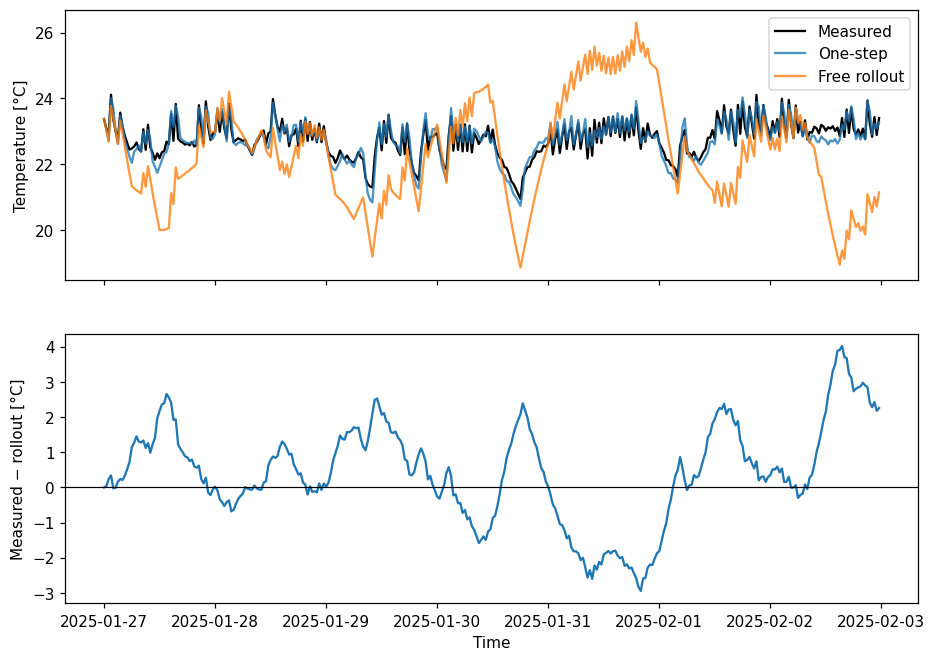

In [11]:
def rmse(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    if actual.shape != predicted.shape:
        raise ValueError("Actual and predicted values must have the same shape.")
    return float(np.sqrt(np.mean((actual - predicted) ** 2)))


one_step = one_step_predictions(validation_data, loss_coefficient, heat_coefficient)
rollout = rollout_predictions(validation_data, loss_coefficient, heat_coefficient)
actual_one_step = validation_data["indoor_temperature_c"].iloc[1:]
actual_rollout = validation_data["indoor_temperature_c"]

metrics = pd.DataFrame(
    {
        "RMSE [°C]": [
            rmse(actual_one_step, one_step),
            rmse(actual_rollout, rollout),
        ],
        "Bias [°C]": [
            float((one_step - actual_one_step).mean()),
            float((rollout - actual_rollout).mean()),
        ],
    },
    index=["One-step", "Free rollout"],
)
display(metrics.round(3))

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 7))
axes[0].plot(actual_rollout, label="Measured", color="black")
axes[0].plot(one_step, label="One-step", alpha=0.8)
axes[0].plot(rollout, label="Free rollout", alpha=0.8)
axes[0].set_ylabel("Temperature [°C]")
axes[0].legend()
rollout_residual = actual_rollout - rollout
axes[1].plot(rollout_residual)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Measured − rollout [°C]")
axes[1].set_xlabel("Time")
plt.show()

## 7. Residual diagnosis and supplied controller model

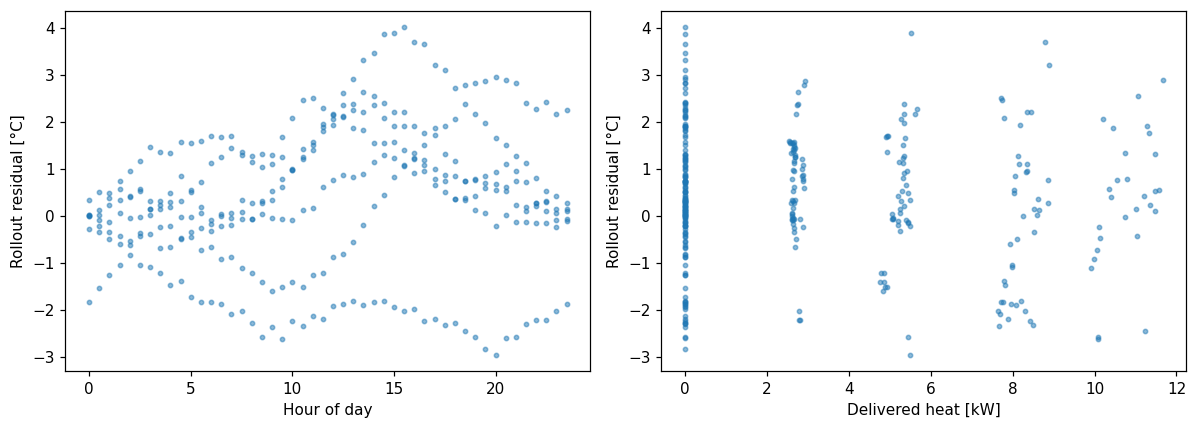

sampling_interval_hours             0.500000
loss_coefficient_per_step           0.023455
heat_coefficient_c_per_kw_step      0.126119
effective_resistance_k_per_kw       5.377088
effective_capacitance_kwh_per_k     3.964502
effective_time_constant_hours      21.317474
nominal_cop                         3.000000
heat_pump_max_electric_kw           5.000000
Name: Verified model, dtype: float64

In [12]:
residual_frame = pd.DataFrame(
    {
        "residual_c": rollout_residual,
        "heating_kw": validation_data["delivered_heat_kw"],
        "hour": validation_data.index.hour + validation_data.index.minute / 60,
    }
).dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(residual_frame["hour"], residual_frame["residual_c"], s=8, alpha=0.5)
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Rollout residual [°C]")
axes[1].scatter(residual_frame["heating_kw"], residual_frame["residual_c"], s=8, alpha=0.5)
axes[1].set_xlabel("Delivered heat [kW]")
axes[1].set_ylabel("Rollout residual [°C]")
plt.tight_layout()
plt.show()

verified_model = json.loads(
    (ROOT / "data" / "reference_building" / "verified_controller_model.json").read_text()
)
display(pd.Series(verified_model, name="Verified model"))

## 8. Optional extension — occupied-house measurements

This extension applies the same identification workflow to measurements from an occupied semi-detached house in the UK. The two files contain five days at 10-minute resolution:

- November 2016, used for calibration;
- June 2017, used for independent validation without refitting.

The available `P_tot (W)` signal is a proxy for heat entering the building, not a direct measurement of useful space-heating output. The solar coefficient also absorbs glazing, shading and other effects. Treat the resulting coefficients and recovered $R$ and $C$ as effective parameters for this data and model.

Source: Hollick, F. and Wingfield, J. (2018), *Two periods of in-situ measurements from an occupied, semi-detached house in the UK*. https://doi.org/10.14324/000.ds.10087216

,Rows,Start,End,Missing selected values
November 2016,720,2016-11-11,2016-11-15 23:50:00,20
June 2017,720,2017-06-10,2017-06-14 23:50:00,24


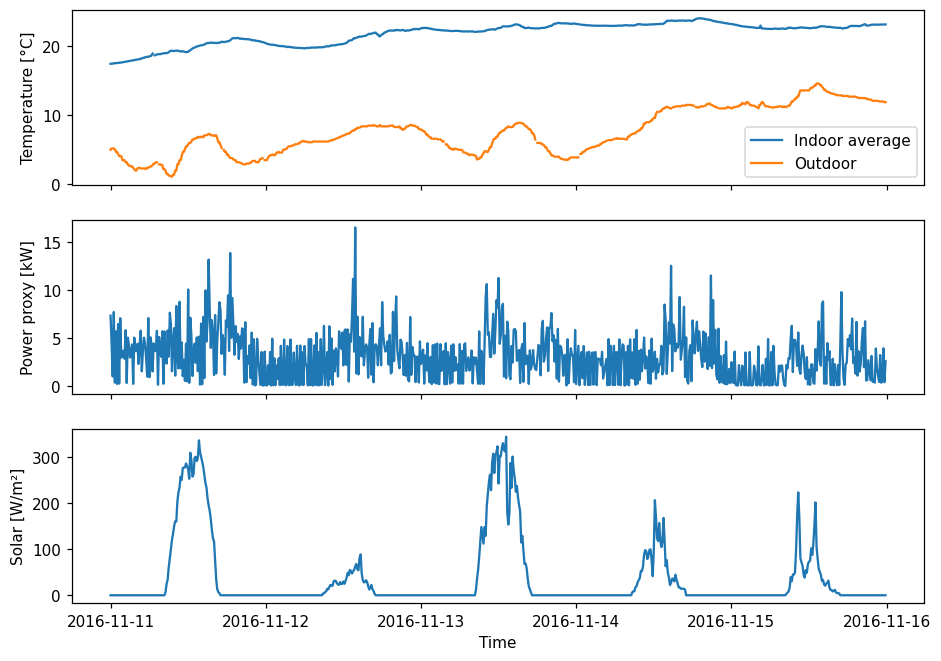

In [13]:
measurement_directory = ROOT / "data" / "tutorial_6_2"


def load_house_period(filename):
    period = pd.read_csv(measurement_directory / filename, index_col=0)
    period.index = pd.to_datetime(period.index, format="%d/%m/%Y %H:%M")
    return period.sort_index()


winter_raw = load_house_period("10mins_solpap_2016.csv")
summer_raw = load_house_period("10mins_solpap_2017.csv")

measurement_summary = pd.DataFrame(
    {
        "Rows": [len(winter_raw), len(summer_raw)],
        "Start": [winter_raw.index.min(), summer_raw.index.min()],
        "End": [winter_raw.index.max(), summer_raw.index.max()],
        "Missing selected values": [
            int(winter_raw[["T_Average (degC)", "T_External (degC)", "P_tot (W)", "Solar (W/m2)"]].isna().sum().sum()),
            int(summer_raw[["T_Average (degC)", "T_External (degC)", "P_tot (W)", "Solar (W/m2)"]].isna().sum().sum()),
        ],
    },
    index=["November 2016", "June 2017"],
)
display(measurement_summary)

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 7))
axes[0].plot(winter_raw["T_Average (degC)"], label="Indoor average")
axes[0].plot(winter_raw["T_External (degC)"], label="Outdoor")
axes[0].set_ylabel("Temperature [°C]")
axes[0].legend()
axes[1].plot(winter_raw["P_tot (W)"] / 1000)
axes[1].set_ylabel("Power proxy [kW]")
axes[2].plot(winter_raw["Solar (W/m2)"])
axes[2].set_ylabel("Solar [W/m²]")
axes[2].set_xlabel("Time")
plt.show()

### Extension Task E1 — prepare the measured data

Interpolate the short measurement gaps separately within each five-day period. This is retrospective model identification, so interpolation across an internal gap is available. Then form

$$
T_{k+1}-T_k=b(T_{o,k}-T_k)+cP^{proxy}_k+gS_k+\varepsilon_k.
$$

Use `P_tot (W)` in kW and scale `Solar (W/m2)` to kW/m² so the fitted coefficients remain numerically convenient.

In [14]:
def prepare_house_measurements(raw_data):
    columns = [
        "T_Average (degC)",
        "T_External (degC)",
        "P_tot (W)",
        "Solar (W/m2)",
    ]
    data = raw_data[columns].copy()
    data = data.interpolate(method="time", limit_direction="both")
    if data.isna().any().any():
        raise ValueError("The selected measurement columns still contain missing values.")

    table = pd.DataFrame(index=data.index)
    table["indoor_temperature_c"] = data["T_Average (degC)"]
    table["outdoor_temperature_c"] = data["T_External (degC)"]
    table["power_proxy_kw"] = data["P_tot (W)"] / 1000
    table["solar_proxy_kw_m2"] = data["Solar (W/m2)"] / 1000
    table["next_indoor_temperature_c"] = table["indoor_temperature_c"].shift(-1)
    table["temperature_change_c"] = (
        table["next_indoor_temperature_c"] - table["indoor_temperature_c"]
    )
    table["temperature_difference_c"] = (
        table["outdoor_temperature_c"] - table["indoor_temperature_c"]
    )
    return table.iloc[:-1]

In [15]:
winter_measurements = prepare_house_measurements(winter_raw)
summer_measurements = prepare_house_measurements(summer_raw)
display(winter_measurements.head(3))

,indoor_temperature_c,outdoor_temperature_c,power_proxy_kw,solar_proxy_kw_m2,next_indoor_temperature_c,temperature_change_c,temperature_difference_c
Date and time,,,,,,,
2016-11-11 00:00:00,17.457,5.0,7.34560,0.0,17.484,0.027,-12.457
2016-11-11 00:10:00,17.484,5.2,4.37856,0.0,17.480,-0.004,-12.284
2016-11-11 00:20:00,17.480,5.2,1.03576,0.0,17.513,0.033,-12.280


### Extension Task E2 — fit on November 2016

Fit the three coefficients using the winter period only. Do not use June 2017 to choose coefficients or bounds.

In [16]:
def fit_house_measurement_model(measurement_table):
    feature_columns = [
        "temperature_difference_c",
        "power_proxy_kw",
        "solar_proxy_kw_m2",
    ]
    design = measurement_table[feature_columns].to_numpy()
    target = measurement_table["temperature_change_c"].to_numpy()
    result = lsq_linear(
        design,
        target,
        bounds=([1e-6, 1e-6, 0.0], [0.2, 0.5, 2.0]),
    )
    if not result.success:
        raise RuntimeError(result.message)
    return result.x

In [17]:
house_coefficients = fit_house_measurement_model(winter_measurements)
house_loss_coefficient, house_power_coefficient, house_solar_coefficient = house_coefficients

house_step_hours = 1 / 6
house_effective_r = house_power_coefficient / house_loss_coefficient
house_effective_c = house_step_hours / house_power_coefficient
house_effective_tau = house_step_hours / house_loss_coefficient

print(f"Loss coefficient: {house_loss_coefficient:.6f}")
print(f"Power-proxy coefficient: {house_power_coefficient:.6f}")
print(f"Solar coefficient: {house_solar_coefficient:.6f}")
print(f"Effective R under the proxy assumption: {house_effective_r:.2f} K/kW")
print(f"Effective C under the proxy assumption: {house_effective_c:.2f} kWh/K")
print(f"Effective time constant: {house_effective_tau:.1f} h")

Loss coefficient: 0.000800
Power-proxy coefficient: 0.005328
Solar coefficient: 0.068648
Effective R under the proxy assumption: 6.66 K/kW
Effective C under the proxy assumption: 31.28 kWh/K
Effective time constant: 208.2 h


### Extension Task E3 — test without refitting

Compare one-step prediction and a free rollout on both periods. The 2017 period is a demanding test because it has warmer weather and much less gas use than the calibration period.

In [18]:
def predict_house_measurements(measurement_table, coefficients):
    loss_coefficient, power_coefficient, solar_coefficient = coefficients
    valid_index = measurement_table.index + pd.Timedelta(minutes=10)

    one_step_values = (
        measurement_table["indoor_temperature_c"].to_numpy()
        + measurement_table[
            ["temperature_difference_c", "power_proxy_kw", "solar_proxy_kw_m2"]
        ].to_numpy()
        @ coefficients
    )
    one_step = pd.Series(one_step_values, index=valid_index, name="one_step_c")

    predicted_temperature = float(measurement_table["indoor_temperature_c"].iloc[0])
    rollout_values = []
    for _, row in measurement_table.iterrows():
        predicted_temperature = (
            predicted_temperature
            + loss_coefficient
            * (row["outdoor_temperature_c"] - predicted_temperature)
            + power_coefficient * row["power_proxy_kw"]
            + solar_coefficient * row["solar_proxy_kw_m2"]
        )
        rollout_values.append(predicted_temperature)

    rollout = pd.Series(rollout_values, index=valid_index, name="free_rollout_c")
    actual = pd.Series(
        measurement_table["next_indoor_temperature_c"].to_numpy(),
        index=valid_index,
        name="measured_c",
    )
    return actual, one_step, rollout

,One-step RMSE [°C],Free-rollout RMSE [°C],Free-rollout bias [°C]
2016 calibration,0.049,1.079,-0.766
2017 validation,0.035,5.076,4.502


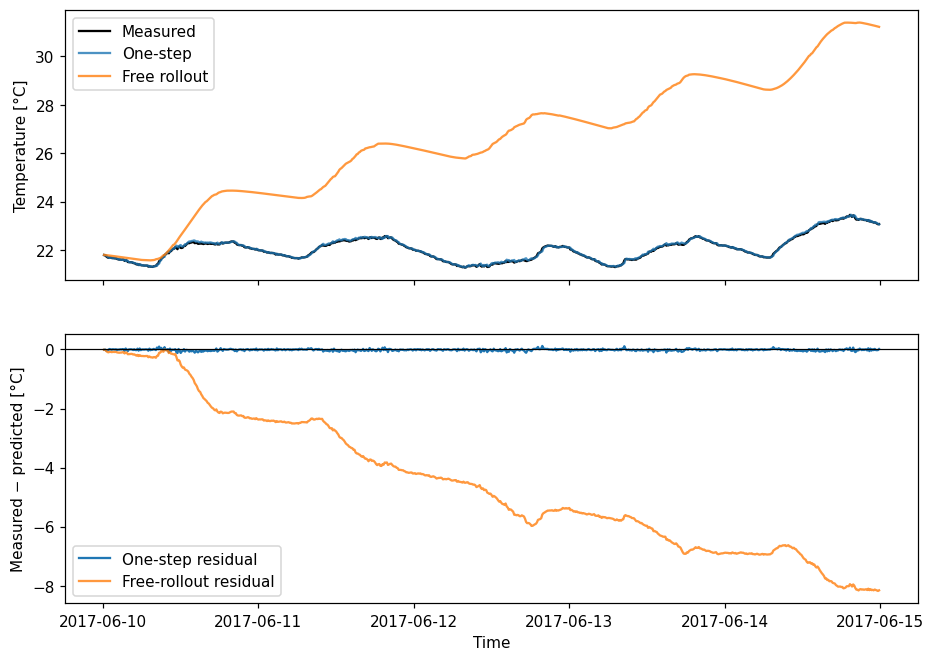

In [19]:
house_results = {}
house_metrics = {}
for period_name, period_table in {
    "2016 calibration": winter_measurements,
    "2017 validation": summer_measurements,
}.items():
    actual, one_step_house, rollout_house = predict_house_measurements(
        period_table, house_coefficients
    )
    house_results[period_name] = (actual, one_step_house, rollout_house)
    house_metrics[period_name] = {
        "One-step RMSE [°C]": rmse(actual, one_step_house),
        "Free-rollout RMSE [°C]": rmse(actual, rollout_house),
        "Free-rollout bias [°C]": float((rollout_house - actual).mean()),
    }

house_metric_table = pd.DataFrame(house_metrics).T
display(house_metric_table.round(3))

actual, one_step_house, rollout_house = house_results["2017 validation"]
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 7))
axes[0].plot(actual, label="Measured", color="black")
axes[0].plot(one_step_house, label="One-step", alpha=0.8)
axes[0].plot(rollout_house, label="Free rollout", alpha=0.8)
axes[0].set_ylabel("Temperature [°C]")
axes[0].legend()
axes[1].plot(actual - one_step_house, label="One-step residual")
axes[1].plot(actual - rollout_house, label="Free-rollout residual", alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Measured − predicted [°C]")
axes[1].set_xlabel("Time")
axes[1].legend()
plt.show()

### Extension questions

1. Why can the one-step RMSE remain small while the free rollout drifts substantially?
2. How do the June 2017 operating conditions differ from the November 2016 calibration period?
3. Why should coefficients based on `P_tot (W)` be treated as effective rather than physical parameters?
4. Which additional measurements would make the identification problem more physically interpretable?

## Discussion

1. Why is the rollout error larger than the one-step error?
2. Which omitted effects could explain a residual pattern by hour of day?
3. Why will later tutorials use the common verified model rather than every student's fitted model?
4. Over what horizon and operating range does the fitted model appear credible?